[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RogerioLS/production-ai-systems/blob/main/docs/notebooks/a_llm_basics/attention_playground.ipynb)

# 🧠 Attention Mechanics & Multi-Head Linear Algebra Playground

Welcome to the interactive playground for **LAB-03 (Attention from Scratch)**.

This notebook allows you to:
1. Run Scaled Dot-Product Attention step-by-step.
2. Visualize bidirectional self-attention weights vs causal (autoregressive) masked weights.
3. Interact with Multi-Head Attention parameters and inspect tensor dimensionality changes.

---

### 0. Environment Setup
If you are running in Google Colab, this cell will automatically clone the repository and install all required dependencies (like `torch` and `matplotlib`). If running locally, it does nothing.

In [2]:
import os
import sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab! Cloning repository...")
    !git clone https://github.com/RogerioLS/production-ai-systems.git
    sys.path.append("/content/production-ai-systems")
    os.chdir("/content/production-ai-systems")
    !pip install -e ".[dev,docs]"
else:
    print("Running locally. Make sure dependencies from pyproject.toml are installed.")

Running locally. Make sure dependencies from pyproject.toml are installed.


### 1. Imports

In [3]:
# Ensure project root is in the path when running locally
if not IN_COLAB:
    import sys
    import os
    sys.path.append(os.path.abspath("../../../"))

import torch
import matplotlib.pyplot as plt

from projects.a_llm_basics.src.lab_03_attention.attention import (
    ScaledDotProductAttention,
    MultiHeadAttention,
)
print("Modules imported successfully!")

Modules imported successfully!


### 2. Run Scaled Dot-Product Attention

In [4]:
# Setup synthetic sequence
tokens = ["The", "quick", "brown", "fox", "jumps", "over", "the", "lazy", "dog"]
seq_len = len(tokens)
d_model = 16

torch.manual_seed(42)
q = torch.randn(1, seq_len, d_model)
k = torch.randn(1, seq_len, d_model)
v = torch.randn(1, seq_len, d_model)

attention = ScaledDotProductAttention()

# 1. Unmasked Attention
out_bidir, weights_bidir = attention(q, k, v)
print("Bidirectional output shape:", out_bidir.shape)
print("Bidirectional weights shape:", weights_bidir.shape)

# 2. Causal Masked Attention
mask = torch.tril(torch.ones(seq_len, seq_len)).bool()
out_causal, weights_causal = attention(q, k, v, mask=mask)
print("Causal output shape:", out_causal.shape)
print("Causal weights shape:", weights_causal.shape)

Bidirectional output shape: torch.Size([1, 9, 16])
Bidirectional weights shape: torch.Size([1, 9, 9])
Causal output shape: torch.Size([1, 9, 16])
Causal weights shape: torch.Size([1, 9, 9])


### 3. Visualize Attention Matrices

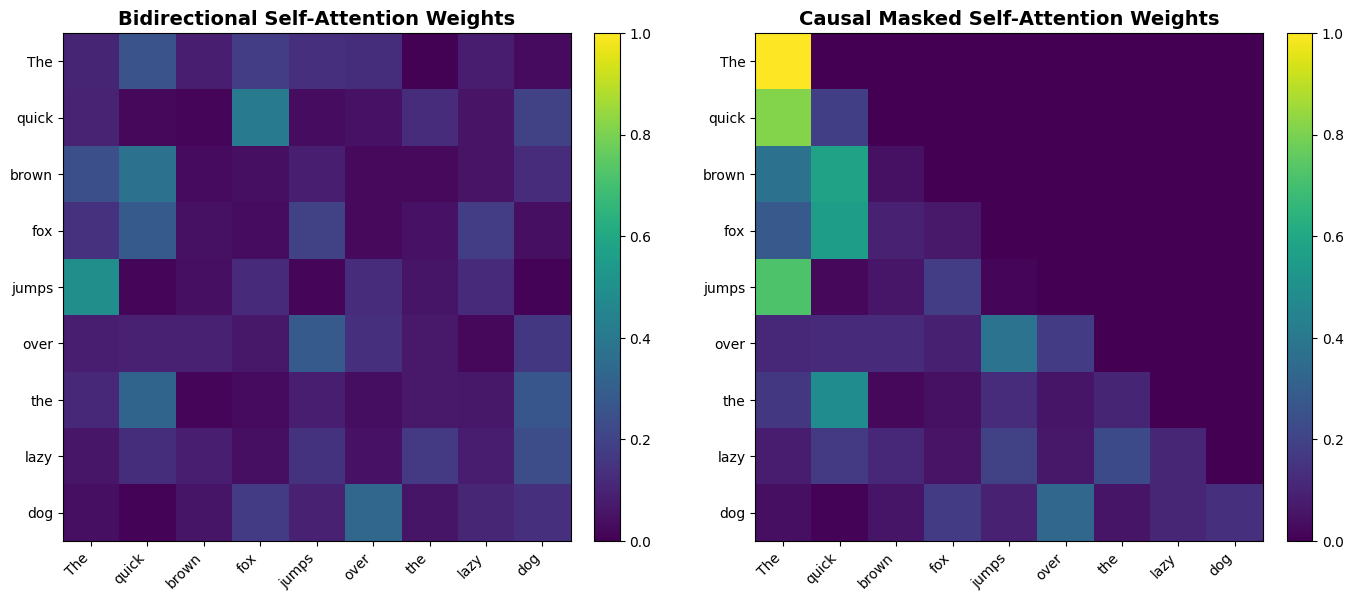

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bidirectional
im1 = ax1.imshow(weights_bidir.squeeze(0).detach().numpy(), cmap="viridis", vmin=0, vmax=1)
ax1.set_title("Bidirectional Self-Attention Weights", fontsize=14, fontweight="bold")
ax1.set_xticks(range(seq_len))
ax1.set_yticks(range(seq_len))
ax1.set_xticklabels(tokens, rotation=45, ha="right")
ax1.set_yticklabels(tokens)
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Causal
im2 = ax2.imshow(weights_causal.squeeze(0).detach().numpy(), cmap="viridis", vmin=0, vmax=1)
ax2.set_title("Causal Masked Self-Attention Weights", fontsize=14, fontweight="bold")
ax2.set_xticks(range(seq_len))
ax2.set_yticks(range(seq_len))
ax2.set_xticklabels(tokens, rotation=45, ha="right")
ax2.set_yticklabels(tokens)
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()